In [24]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [25]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"] = housing.target

In [26]:
x = data[['AveRooms']].values
y = data['Price'].values

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.3,
    random_state=42
)

In [28]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [36]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(x_train_scaled)
cost_history= [ ]

for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    
    w = w - learning_rate *dw
    b= b -learning_rate *db

    if i % 100 ==0:
        cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
        print(f"Epoch {i}, cost ={cost :4f}")
        cost_history.append(cost)
y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, cost =2.810724
Epoch 100, cost =0.943260
Epoch 200, cost =0.693058
Epoch 300, cost =0.659536
Epoch 400, cost =0.655045
Epoch 500, cost =0.654443
Epoch 600, cost =0.654363
Epoch 700, cost =0.654352
Epoch 800, cost =0.654350
Epoch 900, cost =0.654350


In [37]:
print("Gradient Descent")
print("---------------")
print("weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))


Gradient Descent
---------------
weight: 0.17604840899322222
Bias: 2.069150277287304
MSE: 1.28240569543881
R2 Score: 0.022958850701518485


In [38]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test), 1)), x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta

In [39]:
print("\nNormal Equation")
print("-----------------")
print("Intercept :",theta[1])
print("slope:", theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test, y_pred_ne))


Normal Equation
-----------------
Intercept : 0.07175754246283568
slope: 0.07175754246283568
MSE: 1.2824058156409508
R2 Score: 0.022958759121733507


In [40]:
sort_axis = np.argsort(x_test.flatten())
x_soreted = x_test[sort_axis]
y_pred_ne_sored = y_pred_ne[sort_axis]

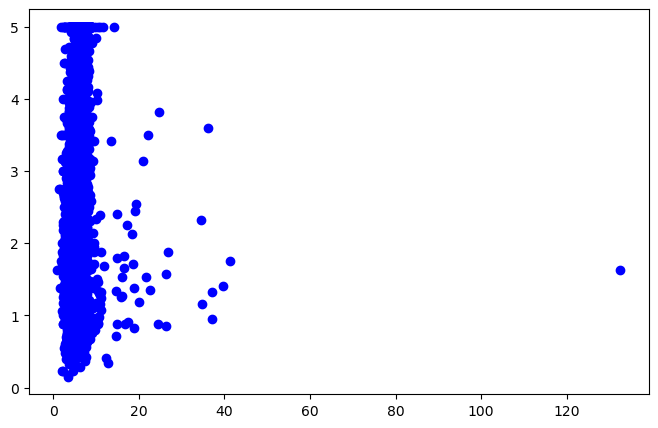

In [41]:
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, color='blue',label ='Actual Data')


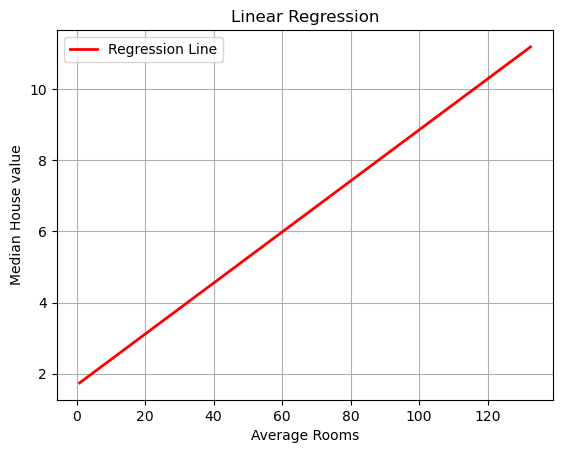

In [42]:
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House value")
plt.legend()
plt.grid(True)
plt.show()

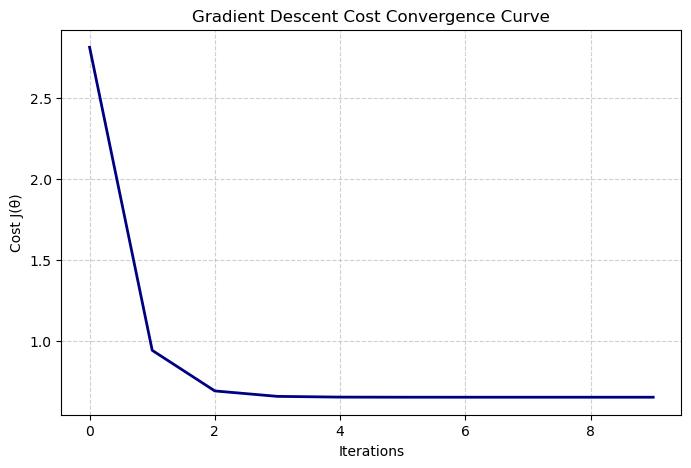

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color='navy', linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(θ)')

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()